# Beta-Distribution GDD Model II — *Prunus yedoensis* + *sargentii* (Japan)

Trains three `BetaGDD` variants on the GMU Japan dataset with **both** cherry
species (*Prunus yedoensis* / Somei-yoshino and *P. sargentii* / Oyama cherry)
and compares their performance.

| Model | Context | Chilling curve |
|---|---|---|
| `GlobalBetaGDDModel` | None — single global α, β | Learnable bounds + width regulariser |
| `OneHotSpeciesBetaGDDModel` | One-hot species encoding | Per-species α, β; fixed Utah bounds [1.4, 15.9] °C |
| `PhylogeneticBetaGDDModel` | Phylogenetic MDS coords (z-scored) | Per-species α, β; fixed Utah bounds [1.4, 15.9] °C |

## Config

In [106]:
import torch

OBS_KEY = 'gmu_0'
CUTOFF  = 2015          # train: ≤2014, test: ≥2015
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

# Beta-GDD temperature range (fixed bounds for contextual models)
T_LOW  = -5.0
T_HIGH = 20.0

# Training
NUM_EPOCHS  = 1000
BATCH_SIZE  = 512

# Style helpers
_MONTH_STARTS = [0, 31, 61, 92, 122, 153, 181, 212, 243, 273, 304, 334]
_MONTH_LABELS = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar',
                 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']

COLORS = {
    'global':   '#1a6b3c',
    'one_hot':  '#2563eb',
    'phylo':    '#9333ea',
}

def _month_ticks(n):
    t = [d for d in _MONTH_STARTS if d < n]
    l = [_MONTH_LABELS[i] for i, d in enumerate(_MONTH_STARTS) if d < n]
    return t, l

def _style_ax(ax, n, ylabel='', xlabel=False):
    ax.set_xlim(0, n - 1)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    t, l = _month_ticks(n)
    ax.set_xticks(t)
    ax.set_xticklabels(l if xlabel else [], fontsize=8)
    if xlabel:
        ax.set_xlabel('Month (season from Oct 1)', fontsize=9)

Device: cuda


## 1. Load data

Both species from the combined YS dataset:
- `species_id = 0` → *Prunus yedoensis* (Somei-yoshino)
- `species_id = 1` → *Prunus sargentii* (Oyama cherry)

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F

from pysephone.constants import KEY_FEATURES
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.feature_cache import FeatureCache
from pysephone.dataset.util.phylogeny import PhylogenyFeatures
from pysephone.evaluation.regression import SingleTargetRegression
from pysephone.models.beta_gdd import (
    GlobalBetaGDDModel,
    OneHotSpeciesBetaGDDModel,
    PhylogeneticBetaGDDModel,
)

In [108]:
DATA_KEYS = ['temperature_2m_mean']

cal    = Calendar(default_start='10-01', default_length=365)
_cache = FeatureCache.load(FeatureCache.default_path('GMU_Cherry_Japan_YS', DATA_KEYS))
ds_all = Dataset.load('GMU_Cherry_Japan_YS', calendar=cal, feature_providers=[_cache])

# Both species
ds_ys  = ds_all.select_species([('GMU_cherry', 0), ('GMU_cherry', 1)])

target_fn = lambda s: s['observations'][OBS_KEY]

species_counts = {}
for ix in ds_ys.iter_index():
    sid = int(ix[3])
    species_counts[sid] = species_counts.get(sid, 0) + 1

SPECIES_NAMES = {0: 'Prunus yedoensis', 1: 'Prunus sargentii'}
for sid, cnt in sorted(species_counts.items()):
    print(f'  species_id={sid}  {SPECIES_NAMES[sid]:<24s}  {cnt} samples')
print(f'Total: {len(ds_ys)} samples')

  species_id=0  Prunus yedoensis          1997 samples
  species_id=1  Prunus sargentii          225 samples
Total: 2222 samples


## 2. Temporal train / test split

In [109]:
years_trn = [y for y in ds_ys.years if y < CUTOFF]
years_tst = [y for y in ds_ys.years if y >= CUTOFF]

ds_trn = ds_ys.select_years(years_trn)
ds_tst = ds_ys.select_years(years_tst)

print(f'Train: {len(ds_trn)} samples  ({min(years_trn)}–{max(years_trn)})')
print(f'Test:  {len(ds_tst)} samples  ({min(years_tst)}–{max(years_tst)})')

Train: 1914 samples  (1986–2014)
Test:  308 samples  (2015–2021)


## 3. Model 1: `GlobalBetaGDDModel` with learnable bounds

Same single global α and β for both species, but now the temperature range
`[t_low, t_high]` is learned too.  A regularisation term
`λ × (t_high − t_low)` penalises unnecessarily wide windows, so the bounds
only expand when the data supports it.

In [110]:
MODEL_KWARGS_GLOBAL = dict(
    t_low             = T_LOW,
    t_high            = T_HIGH,
    learn_bounds      = True,
    bounds_reg_lambda = 0.01,
    bounds_min_width  = 5.0,
    alpha_init        = 2.0,
    beta_init         = 2.0,
    learn_alpha_beta  = True,
    learn_t_base      = True,
    t_base_init       = 5.0,
    learn_thresholds  = True,
)

model_global, fit_global = GlobalBetaGDDModel.fit(
    target_fn        = target_fn,
    dataset          = ds_trn,
    model_kwargs     = MODEL_KWARGS_GLOBAL,
    num_epochs       = NUM_EPOCHS,
    batch_size       = BATCH_SIZE,
    val_period       = 10,
    optimizer        = 'adam',
    optimizer_kwargs = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 100,
    scheduler_decay          = 0.9,
    early_stopping           = True,
    early_stopping_patience  = 10,
    early_stopping_min_delta = 1e-3,
    device  = DEVICE,
    verbose = True,
)
print('Global model training complete.')

GlobalBetaGDDModel epoch [    1/1000] lr=1.00e-03 loss=0.46369: 100%|██████████| 3/3 [00:00<00:00, 95.40it/s]
GlobalBetaGDDModel epoch [    2/1000] lr=1.00e-03 loss=0.45478: 100%|██████████| 3/3 [00:00<00:00, 84.46it/s]
GlobalBetaGDDModel epoch [    3/1000] lr=1.00e-03 loss=0.44743: 100%|██████████| 3/3 [00:00<00:00, 81.82it/s]
GlobalBetaGDDModel epoch [    4/1000] lr=1.00e-03 loss=0.44199: 100%|██████████| 3/3 [00:00<00:00, 106.07it/s]
GlobalBetaGDDModel epoch [    5/1000] lr=1.00e-03 loss=0.43861: 100%|██████████| 3/3 [00:00<00:00, 75.24it/s]
GlobalBetaGDDModel epoch [    6/1000] lr=1.00e-03 loss=0.43122: 100%|██████████| 3/3 [00:00<00:00, 114.43it/s]
GlobalBetaGDDModel epoch [    7/1000] lr=1.00e-03 loss=0.42684: 100%|██████████| 3/3 [00:00<00:00, 100.81it/s]
GlobalBetaGDDModel epoch [    8/1000] lr=1.00e-03 loss=0.42285: 100%|██████████| 3/3 [00:00<00:00, 113.72it/s]
GlobalBetaGDDModel epoch [    9/1000] lr=1.00e-03 loss=0.41842: 100%|██████████| 3/3 [00:00<00:00, 106.07it/s]
Globa

Global model training complete.


In [111]:
# Learned parameters
alpha_g   = model_global.alpha.item()
beta_g    = model_global.beta.item()
t_low_g   = model_global.t_low_eff.item()
t_high_g  = model_global.t_high_eff.item()
mode_norm_g = (alpha_g - 1) / (alpha_g + beta_g - 2)
T_opt_g   = t_low_g + (t_high_g - t_low_g) * mode_norm_g
t_base_g  = model_global._gdd._tb.item()
tt_thr_g  = model_global._tt_unit_threshold.threshold.item() * 200
gdd_thr_g = model_global._gdd_threshold.threshold.item() * 500

print(f'α = {alpha_g:.3f},  β = {beta_g:.3f}')
print(f't_low  = {t_low_g:.2f} °C  (init {T_LOW:.0f} °C)')
print(f't_high = {t_high_g:.2f} °C  (init {T_HIGH:.0f} °C)')
print(f'Window width = {t_high_g - t_low_g:.2f} °C')
print(f'T_opt  = {T_opt_g:.1f} °C')
print(f't_base = {t_base_g:.2f} °C')
print(f'Chilling threshold ≈ {tt_thr_g:.1f} cum. units')
print(f'Forcing threshold  ≈ {gdd_thr_g:.1f} GDD')

α = 1.547,  β = 1.539
t_low  = -4.60 °C  (init -5 °C)
t_high = 19.63 °C  (init 20 °C)
Window width = 24.22 °C
T_opt  = 7.6 °C
t_base = 5.51 °C
Chilling threshold ≈ 123.2 cum. units
Forcing threshold  ≈ 106.4 GDD


## 4. Model 2: `OneHotSpeciesBetaGDDModel` with context-predicted α, β

A small MLP maps a one-hot species encoding to per-species `(α, β)` shape parameters.
Temperature bounds are fixed at the Utah model's positive-chilling range [1.4, 15.9] °C.
Weight decay is disabled for the context MLP to prevent shape collapse.

In [112]:
MODEL_KWARGS_OH = dict(
    t_low             = 1.4,   # Utah model lower positive-chilling threshold
    t_high            = 15.9,  # Utah model upper positive-chilling threshold
    learn_t_base      = True,
    t_base_init       = 5.0,
    learn_thresholds  = True,
    ctx_hidden        = 16,
)

onehot_model = OneHotSpeciesBetaGDDModel.from_dataset(ds_trn, **MODEL_KWARGS_OH)
print('One-hot species context dim:', onehot_model._ctx_dim)

model_onehot, fit_onehot = OneHotSpeciesBetaGDDModel.fit(
    target_fn        = target_fn,
    dataset          = ds_trn,
    model            = onehot_model,
    num_epochs       = NUM_EPOCHS,
    batch_size       = BATCH_SIZE,
    val_period       = 10,
    optimizer        = 'adam',
    optimizer_kwargs = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 100,
    scheduler_decay          = 0.9,
    early_stopping           = True,
    early_stopping_patience  = 10,
    early_stopping_min_delta = 1e-3,
    device  = DEVICE,
    verbose = True,
)
print('One-hot model training complete.')

One-hot species context dim: 2


OneHotSpeciesBetaGDDModel epoch [    1/1000] lr=1.00e-03 loss=0.96500: 100%|██████████| 3/3 [00:00<00:00, 15.82it/s]
OneHotSpeciesBetaGDDModel epoch [    2/1000] lr=1.00e-03 loss=0.90603: 100%|██████████| 3/3 [00:00<00:00, 16.27it/s]
OneHotSpeciesBetaGDDModel epoch [    3/1000] lr=1.00e-03 loss=0.87315: 100%|██████████| 3/3 [00:00<00:00, 15.95it/s]
OneHotSpeciesBetaGDDModel epoch [    4/1000] lr=1.00e-03 loss=0.81508: 100%|██████████| 3/3 [00:00<00:00, 16.60it/s]
OneHotSpeciesBetaGDDModel epoch [    5/1000] lr=1.00e-03 loss=0.78533: 100%|██████████| 3/3 [00:00<00:00, 15.06it/s]
OneHotSpeciesBetaGDDModel epoch [    6/1000] lr=1.00e-03 loss=0.74431: 100%|██████████| 3/3 [00:00<00:00, 17.72it/s]
OneHotSpeciesBetaGDDModel epoch [    7/1000] lr=1.00e-03 loss=0.71345: 100%|██████████| 3/3 [00:00<00:00, 18.53it/s]
OneHotSpeciesBetaGDDModel epoch [    8/1000] lr=1.00e-03 loss=0.68141: 100%|██████████| 3/3 [00:00<00:00, 16.45it/s]
OneHotSpeciesBetaGDDModel epoch [    9/1000] lr=1.00e-03 loss=0.

One-hot model training complete.


## 5. Model 3: `PhylogeneticBetaGDDModel` with context-predicted α, β

Same as the one-hot model but the context is a phylogenetic MDS embedding.
Each species gets its own `(α, β)` predicted from its position in phylogenetic space,
with the same fixed Utah-model bounds.

In [113]:
# PhylogenyFeatures.fit() needs observations.species_names, which the GMU
# dataset doesn't populate.  Provide it via a minimal stub.
class _SpeciesNameStub:
    def __init__(self, names):
        self.species_names = names

_names = {
    ('GMU_cherry', 0): 'Prunus yedoensis',
    ('GMU_cherry', 1): 'Prunus sargentii',
}

phylo = PhylogenyFeatures(k_embed=4, output=['mds'])
phylo.fit(_SpeciesNameStub(_names))
print('Phylogeny fitted.  Species:', phylo.species_keys)
print('MDS coords shape:', phylo.mds_coords.shape)

Phylogeny fitted.  Species: [('GMU_cherry', 0), ('GMU_cherry', 1)]
MDS coords shape: (2, 1)


In [114]:
MODEL_KWARGS_PHYLO = dict(
    t_low             = 1.4,   # Utah model lower positive-chilling threshold
    t_high            = 15.9,  # Utah model upper positive-chilling threshold
    learn_t_base      = True,
    t_base_init       = 5.0,
    learn_thresholds  = True,
    ctx_hidden        = 16,
)

phylo_model = PhylogeneticBetaGDDModel.from_phylogeny_features(phylo, **MODEL_KWARGS_PHYLO)
print('Phylogenetic context dim:', phylo_model._ctx_dim)

model_phylo, fit_phylo = PhylogeneticBetaGDDModel.fit(
    target_fn        = target_fn,
    dataset          = ds_trn,
    model            = phylo_model,
    num_epochs       = NUM_EPOCHS,
    batch_size       = BATCH_SIZE,
    val_period       = 10,
    optimizer        = 'adam',
    optimizer_kwargs = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 100,
    scheduler_decay          = 0.9,
    early_stopping           = True,
    early_stopping_patience  = 10,
    early_stopping_min_delta = 1e-3,
    device  = DEVICE,
    verbose = True,
)
print('Phylogenetic model training complete.')

Phylogenetic context dim: 1


PhylogeneticBetaGDDModel epoch [    1/1000] lr=1.00e-03 loss=1.04615: 100%|██████████| 3/3 [00:00<00:00, 83.25it/s]
PhylogeneticBetaGDDModel epoch [    2/1000] lr=1.00e-03 loss=0.98023: 100%|██████████| 3/3 [00:00<00:00, 71.68it/s]
PhylogeneticBetaGDDModel epoch [    3/1000] lr=1.00e-03 loss=0.93073: 100%|██████████| 3/3 [00:00<00:00, 57.98it/s]
PhylogeneticBetaGDDModel epoch [    4/1000] lr=1.00e-03 loss=0.86088: 100%|██████████| 3/3 [00:00<00:00, 88.52it/s]
PhylogeneticBetaGDDModel epoch [    5/1000] lr=1.00e-03 loss=0.82896: 100%|██████████| 3/3 [00:00<00:00, 87.97it/s]
PhylogeneticBetaGDDModel epoch [    6/1000] lr=1.00e-03 loss=0.77270: 100%|██████████| 3/3 [00:00<00:00, 88.12it/s]
PhylogeneticBetaGDDModel epoch [    7/1000] lr=1.00e-03 loss=0.73168: 100%|██████████| 3/3 [00:00<00:00, 88.14it/s]
PhylogeneticBetaGDDModel epoch [    8/1000] lr=1.00e-03 loss=0.69845: 100%|██████████| 3/3 [00:00<00:00, 83.15it/s]
PhylogeneticBetaGDDModel epoch [    9/1000] lr=1.00e-03 loss=0.66797: 10

Phylogenetic model training complete.


## 6. Training loss curves

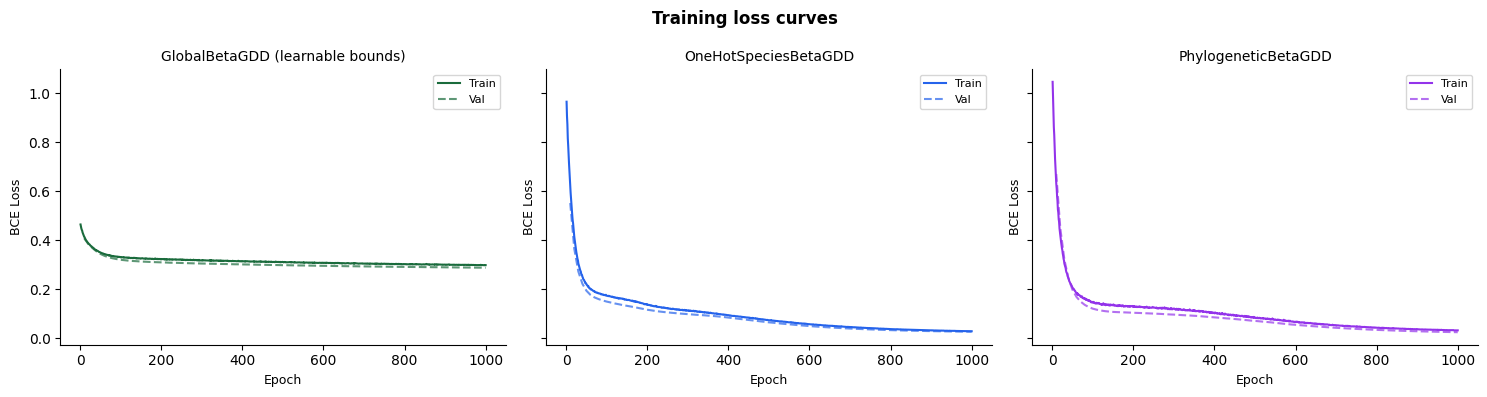

In [115]:
def _extract_loss_curves(fit_info):
    epochs   = [e['epoch'] for e in fit_info['epochs']]
    trn_loss = [e['loss']  for e in fit_info['epochs']]
    val_ep   = [e['epoch'] for e in fit_info['epochs'] if 'val' in e]
    val_loss = [e['val']['loss'] for e in fit_info['epochs'] if 'val' in e]
    return epochs, trn_loss, val_ep, val_loss


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle('Training loss curves', fontsize=12, fontweight='bold')

for ax, fit_info, name, color in zip(
    axes,
    [fit_global, fit_onehot, fit_phylo],
    ['GlobalBetaGDD (learnable bounds)', 'OneHotSpeciesBetaGDD', 'PhylogeneticBetaGDD'],
    [COLORS['global'], COLORS['one_hot'], COLORS['phylo']],
):
    ep, trn, vep, val = _extract_loss_curves(fit_info)
    ax.plot(ep, trn, color=color, lw=1.5, label='Train')
    if val:
        ax.plot(vep, val, color=color, lw=1.5, ls='--', alpha=0.7, label='Val')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel('BCE Loss', fontsize=9)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Evaluation — overall

In [116]:
results = {}
for name, model in [
    ('Global (learnable bounds)', model_global),
    ('OneHot Species',            model_onehot),
    ('Phylogenetic',              model_phylo),
]:
    res = SingleTargetRegression.run(
        model         = model,
        dataset_train = ds_trn,
        dataset_test  = ds_tst,
        target_fn     = target_fn,
        run_name      = name,
    )
    results[name] = res

rows = []
for name, res in results.items():
    m = res.compute_metrics()
    for split in ('train', 'test'):
        rows.append({
            'Model': name,
            'Split': split,
            'N':     m[split]['n'],
            'RMSE':  round(m[split]['rmse'], 2),
            'MAE':   round(m[split]['mae'],  2),
            'Bias':  round(m[split]['bias'], 2),
            'R²':    round(m[split]['r2'],   3),
        })

df = pd.DataFrame(rows).set_index(['Model', 'Split'])
df

N   RMSE   MAE  Bias     R²
Model                     Split                                
Global (learnable bounds) train  1914  10.20  6.52  0.36  0.430
                          test    308   7.42  5.71 -0.97  0.616
OneHot Species            train  1914   5.74  3.94  0.78  0.819
                          test    308   4.33  3.02  0.67  0.869
Phylogenetic              train  1914   6.38  4.35  0.59  0.777
                          test    308   4.75  3.35  0.32  0.843

## 8. Predicted vs observed scatter — all models

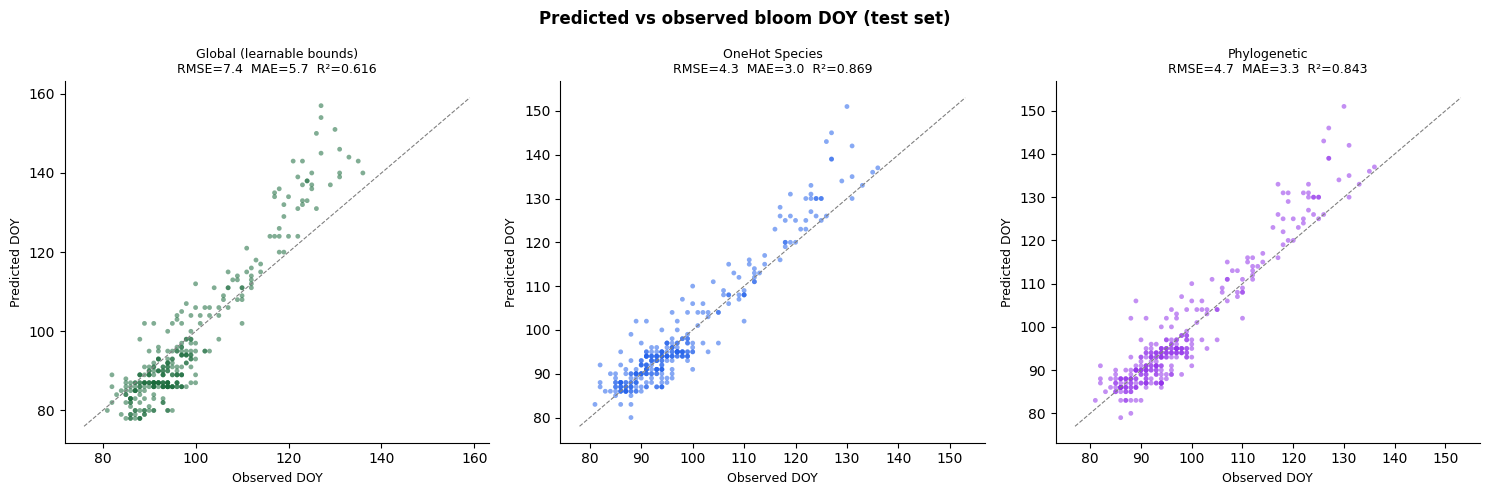

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Predicted vs observed bloom DOY (test set)', fontsize=12, fontweight='bold')

for ax, (name, res), color in zip(
    axes,
    results.items(),
    [COLORS['global'], COLORS['one_hot'], COLORS['phylo']],
):
    df = res.df_test
    ax.scatter(df['observed_doy'], df['predicted_doy'],
               s=12, color=color, alpha=0.55, edgecolors='none')
    lo = min(df['observed_doy'].min(), df['predicted_doy'].min()) - 2
    hi = max(df['observed_doy'].max(), df['predicted_doy'].max()) + 2
    ax.plot([lo, hi], [lo, hi], color='grey', lw=0.8, ls='--')
    m = res.compute_metrics()['test']
    ax.set_title(
        f'{name}\nRMSE={m["rmse"]:.1f}  MAE={m["mae"]:.1f}  R²={m["r2"]:.3f}',
        fontsize=9,
    )
    ax.set_xlabel('Observed DOY', fontsize=9)
    ax.set_ylabel('Predicted DOY', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Per-species evaluation

Break down test metrics by species to see whether the contextual models
actually improve the fit for each species separately.

In [118]:
def per_species_metrics(res, ds_tst):
    """Compute RMSE, MAE, bias per species_id from a SingleTargetRegression result."""
    df = res.df_test.copy()
    # Attach species_id from the dataset index (same order as iter_index)
    indices = list(ds_tst.iter_index())
    df['species_id'] = [int(ix[3]) for ix in indices]

    rows = []
    for sid in sorted(df['species_id'].unique()):
        sub = df[df['species_id'] == sid]
        resid = sub['predicted_doy'] - sub['observed_doy']
        rows.append({
            'species_id': sid,
            'name':       SPECIES_NAMES.get(sid, str(sid)),
            'N':          len(sub),
            'RMSE':       round(float(np.sqrt(np.mean(resid ** 2))), 2),
            'MAE':        round(float(np.mean(np.abs(resid))), 2),
            'Bias':       round(float(np.mean(resid)), 2),
        })
    return rows


all_rows = []
for model_name, res in results.items():
    for row in per_species_metrics(res, ds_tst):
        all_rows.append({'Model': model_name, **row})

df_sp = pd.DataFrame(all_rows).set_index(['Model', 'name'])
df_sp

species_id    N   RMSE    MAE  \
Model                     name                                              
Global (learnable bounds) Prunus yedoensis           0  280   6.00   4.86   
                          Prunus sargentii           1   28  15.67  14.25   
OneHot Species            Prunus yedoensis           0  280   3.73   2.71   
                          Prunus sargentii           1   28   8.21   6.04   
Phylogenetic              Prunus yedoensis           0  280   4.16   3.03   
                          Prunus sargentii           1   28   8.67   6.54   

                                             Bias  
Model                     name                     
Global (learnable bounds) Prunus yedoensis  -2.49  
                          Prunus sargentii  14.25  
OneHot Species            Prunus yedoensis   0.14  
                          Prunus sargentii   5.96  
Phylogenetic              Prunus yedoensis  -0.29  
                          Prunus sargentii   6.46

## 10. Learned chilling response curves

For the contextual models we evaluate the beta response for each species
by passing that species' context through the MLP.

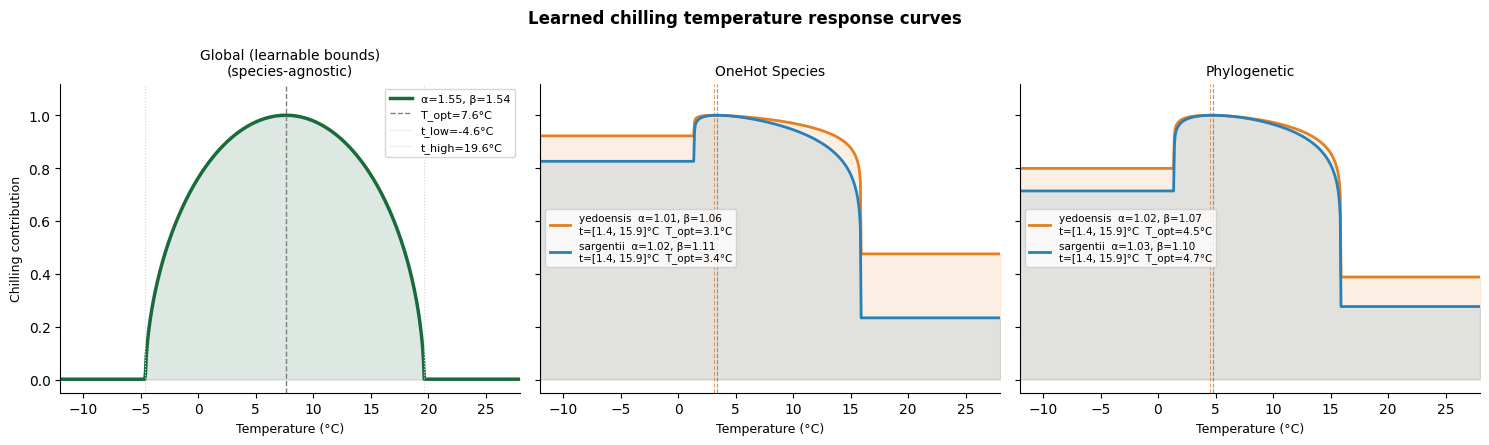

In [119]:
import torch
from pysephone.constants import KEY_DATA_SOURCE, KEY_FEATURES, KEY_SPECIES_ID


def beta_response_curve(alpha, beta, t_low, t_high, t_grid, eps=1e-6):
    T_norm = np.clip((t_grid - t_low) / (t_high - t_low + eps), eps, 1 - eps)
    log_contrib = (alpha - 1) * np.log(T_norm) + (beta - 1) * np.log(1 - T_norm)
    mode = np.clip((alpha - 1) / (alpha + beta - 2), eps, 1 - eps)
    log_max = (alpha - 1) * np.log(mode) + (beta - 1) * np.log(1 - mode)
    return np.exp(log_contrib - log_max)


def get_species_cf_params(model, sid):
    """Return (alpha, beta, t_low, t_high) by running one forward pass."""
    device = next(model.parameters()).device
    dummy_xs = {
        KEY_FEATURES:    {model._temperature_key: torch.zeros(1, 365, device=device)},
        KEY_DATA_SOURCE: ['GMU_cherry'],
        KEY_SPECIES_ID:  torch.tensor([sid], device=device),
    }
    with torch.no_grad():
        _, info = model(dummy_xs)
    # info values may be scalar (0-dim) or (B,) — flatten()[0] handles both
    return tuple(info[k].flatten()[0].item() for k in ('alpha', 'beta', 't_low', 't_high'))


T_GRID = np.linspace(-12, 28, 600)
SP_COLORS = {0: '#e67e22', 1: '#2980b9'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
fig.suptitle('Learned chilling temperature response curves', fontsize=12, fontweight='bold')

# --- Global model: single curve ---
ax = axes[0]
alpha_g, beta_g, t_low_g, t_high_g = get_species_cf_params(model_global, 0)
curve_g = beta_response_curve(alpha_g, beta_g, t_low_g, t_high_g, T_GRID)
T_opt_g = t_low_g + (t_high_g - t_low_g) * (alpha_g - 1) / (alpha_g + beta_g - 2)
ax.fill_between(T_GRID, curve_g, color=COLORS['global'], alpha=0.15)
ax.plot(T_GRID, curve_g, color=COLORS['global'], lw=2.5,
        label=f'α={alpha_g:.2f}, β={beta_g:.2f}')
ax.axvline(T_opt_g,  color='grey',      lw=1.0, ls='--', label=f'T_opt={T_opt_g:.1f}°C')
ax.axvline(t_low_g,  color='lightgrey', lw=0.8, ls=':', label=f't_low={t_low_g:.1f}°C')
ax.axvline(t_high_g, color='lightgrey', lw=0.8, ls=':', label=f't_high={t_high_g:.1f}°C')
ax.set_title('Global (learnable bounds)\n(species-agnostic)', fontsize=10)
ax.legend(fontsize=8)

# --- OneHot + Phylogenetic models: per-species curves ---
for ax, model, name in [
    (axes[1], model_onehot, 'OneHot Species'),
    (axes[2], model_phylo,  'Phylogenetic'),
]:
    for sid, sname in sorted(SPECIES_NAMES.items()):
        alpha, beta, t_low, t_high = get_species_cf_params(model, sid)
        curve = beta_response_curve(alpha, beta, t_low, t_high, T_GRID)
        T_opt = t_low + (t_high - t_low) * (alpha - 1) / (alpha + beta - 2)
        c = SP_COLORS[sid]
        ax.fill_between(T_GRID, curve, color=c, alpha=0.12)
        ax.plot(T_GRID, curve, color=c, lw=2.0,
                label=f'{sname.split()[1]}  α={alpha:.2f}, β={beta:.2f}\n'
                      f't=[{t_low:.1f}, {t_high:.1f}]°C  T_opt={T_opt:.1f}°C')
        ax.axvline(T_opt, color=c, lw=0.8, ls='--', alpha=0.7)
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=7.5)

for ax in axes:
    ax.set_xlabel('Temperature (°C)', fontsize=9)
    ax.set_ylim(-0.05, 1.12)
    ax.set_xlim(T_GRID[0], T_GRID[-1])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axes[0].set_ylabel('Chilling contribution', fontsize=9)

plt.tight_layout()
plt.show()